In [1]:
!pip install -q kornia kornia-rs
!pip install -q opencv-python-headless matplotlib numpy torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 62.8 MB/s eta 0:00:00


In [2]:
import torch
from kornia.feature import DeDoDe

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

dedode = DeDoDe.from_pretrained(detector_weights="L-upright", descriptor_weights="B-upright")
dedode = dedode.to(device).eval()
print("DeDoDe loaded")

Using device: cuda
Downloading: "https://github.com/Parskatt/DeDoDe/releases/download/dedode_pretrained_models/dedode_detector_L.pth" to /root/.cache/torch/hub/checkpoints/dedode_detector_L.pth


100%|██████████| 55.8M/55.8M [00:05<00:00, 10.1MB/s]


Downloading: "https://github.com/Parskatt/DeDoDe/releases/download/dedode_pretrained_models/dedode_descriptor_B.pth" to /root/.cache/torch/hub/checkpoints/dedode_descriptor_B.pth


100%|██████████| 51.7M/51.7M [00:02<00:00, 20.7MB/s]


DeDoDe loaded


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
dataset_dir = '/content/drive/MyDrive/Dataset Rgb and mine/rgb'
files = sorted(os.listdir(dataset_dir))
print(f"Total images: {len(files)}")
print(files[:5])

Total images: 613
['1305031452.791720.png', '1305031452.823674.png', '1305031452.859642.png', '1305031452.891726.png', '1305031452.923715.png']


In [5]:
print([m for m in dir(dedode) if not m.startswith('_')])

['T_destination', 'add_module', 'apply', 'bfloat16', 'buffers', 'call_super_init', 'children', 'compile', 'cpu', 'cuda', 'describe', 'descriptor', 'detect', 'detector', 'double', 'dump_patches', 'eval', 'extra_repr', 'float', 'forward', 'from_pretrained', 'get_buffer', 'get_extra_state', 'get_parameter', 'get_submodule', 'half', 'ipu', 'load_state_dict', 'modules', 'mtia', 'named_buffers', 'named_children', 'named_modules', 'named_parameters', 'normalizer', 'parameters', 'register_backward_hook', 'register_buffer', 'register_forward_hook', 'register_forward_pre_hook', 'register_full_backward_hook', 'register_full_backward_pre_hook', 'register_load_state_dict_post_hook', 'register_load_state_dict_pre_hook', 'register_module', 'register_parameter', 'register_state_dict_post_hook', 'register_state_dict_pre_hook', 'requires_grad_', 'set_extra_state', 'set_submodule', 'share_memory', 'state_dict', 'to', 'to_empty', 'train', 'training', 'type', 'xpu', 'zero_grad']


In [6]:
help(dedode.detect)

Help on method detect in module kornia.feature.dedode.dedode:

detect(images: torch.Tensor, n: Optional[int] = 10000, apply_imagenet_normalization: bool = True, pad_if_not_divisible: bool = True, crop_h: Optional[int] = None, crop_w: Optional[int] = None) -> Tuple[torch.Tensor, torch.Tensor] method of kornia.feature.dedode.dedode.DeDoDe instance
    Detect keypoints in the input images.

    .. note::
        This method unconditionally sets the model to eval mode via ``self.train(False)``
        so that BatchNorm and Dropout behave deterministically. This is intentional: the
        detector is only used at inference time and its statistics must be frozen.

    Args:
        images: A torch.Tensor of shape :math:`(B, 3, H, W)` containing the input images.
        n: The number of keypoints to detect.
        apply_imagenet_normalization: Whether to apply ImageNet normalization to the input images.
        pad_if_not_divisible: F.pad image shape if not evenly divisible.
        crop_h

In [7]:
help(dedode.describe)

Help on method describe in module kornia.feature.dedode.dedode:

describe(images: torch.Tensor, keypoints: Optional[torch.Tensor] = None, apply_imagenet_normalization: bool = True, pad_if_not_divisible: bool = True, crop_h: Optional[int] = None, crop_w: Optional[int] = None) -> torch.Tensor method of kornia.feature.dedode.dedode.DeDoDe instance
    Describe keypoints in the input images. If keypoints are not provided, returns the dense descriptors.

    .. note::
        This method unconditionally sets the model to eval mode via ``self.train(False)``
        so that BatchNorm and Dropout behave deterministically. This is intentional: the
        descriptor is only used at inference time and its statistics must be frozen.

    Args:
        images: A torch.Tensor of shape :math:`(B, 3, H, W)` containing the input images.
        keypoints: An optional torch.Tensor of shape :math:`(B, N, 2)` containing the detected keypoints.
        apply_imagenet_normalization: Whether to apply ImageN

In [8]:
import cv2
import numpy as np

def load_tensor(filename):
    path = os.path.join(dataset_dir, filename)
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    return tensor.to(device), img_rgb

img1_tensor, img1_rgb = load_tensor(files[0])
img2_tensor, img2_rgb = load_tensor(files[1])

print("img1_tensor shape:", img1_tensor.shape)
print("img2_tensor shape:", img2_tensor.shape)

img1_tensor shape: torch.Size([1, 3, 480, 640])
img2_tensor shape: torch.Size([1, 3, 480, 640])


In [9]:
with torch.no_grad():
    kpts1, scores1 = dedode.detect(img1_tensor, n=10000)
    kpts2, scores2 = dedode.detect(img2_tensor, n=10000)

    desc1 = dedode.describe(img1_tensor, kpts1)
    desc2 = dedode.describe(img2_tensor, kpts2)

print("kpts1 shape:", kpts1.shape)
print("kpts2 shape:", kpts2.shape)
print("desc1 shape:", desc1.shape)
print("desc2 shape:", desc2.shape)

kpts1 shape: torch.Size([1, 10000, 2])
kpts2 shape: torch.Size([1, 10000, 2])
desc1 shape: torch.Size([1, 10000, 256])
desc2 shape: torch.Size([1, 10000, 256])


In [10]:
from kornia.feature import match_smnn

desc1_flat = desc1[0]
desc2_flat = desc2[0]

dists, idxs = match_smnn(desc1_flat, desc2_flat, th=0.98)

print("Number of matches:", len(idxs))
print("Sample idxs:", idxs[:5])

Number of matches: 2310
Sample idxs: tensor([[  2, 443],
        [  3, 740],
        [  4,  48],
        [  7, 254],
        [ 13, 425]], device='cuda:0')


In [11]:
def denormalize_kpts(kpts, H, W):
    # kpts are in [-1, 1], convert to pixel coordinates
    x = (kpts[..., 0] + 1) / 2 * (W - 1)
    y = (kpts[..., 1] + 1) / 2 * (H - 1)
    return torch.stack([x, y], dim=-1)

H, W = img1_rgb.shape[:2]
kpts1_px = denormalize_kpts(kpts1[0], H, W)
kpts2_px = denormalize_kpts(kpts2[0], H, W)

mkpts1 = kpts1_px[idxs[:, 0]].cpu().numpy()
mkpts2 = kpts2_px[idxs[:, 1]].cpu().numpy()

F, mask = cv2.findFundamentalMat(mkpts1, mkpts2, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)

inliers = int(mask.sum()) if mask is not None else 0
total_matches = len(mkpts1)
inlier_ratio = inliers / total_matches if total_matches > 0 else 0

print("Matches:", total_matches)
print("Inliers:", inliers)
print("Inlier ratio: {:.2%}".format(inlier_ratio))

Matches: 2310
Inliers: 1814
Inlier ratio: 78.53%


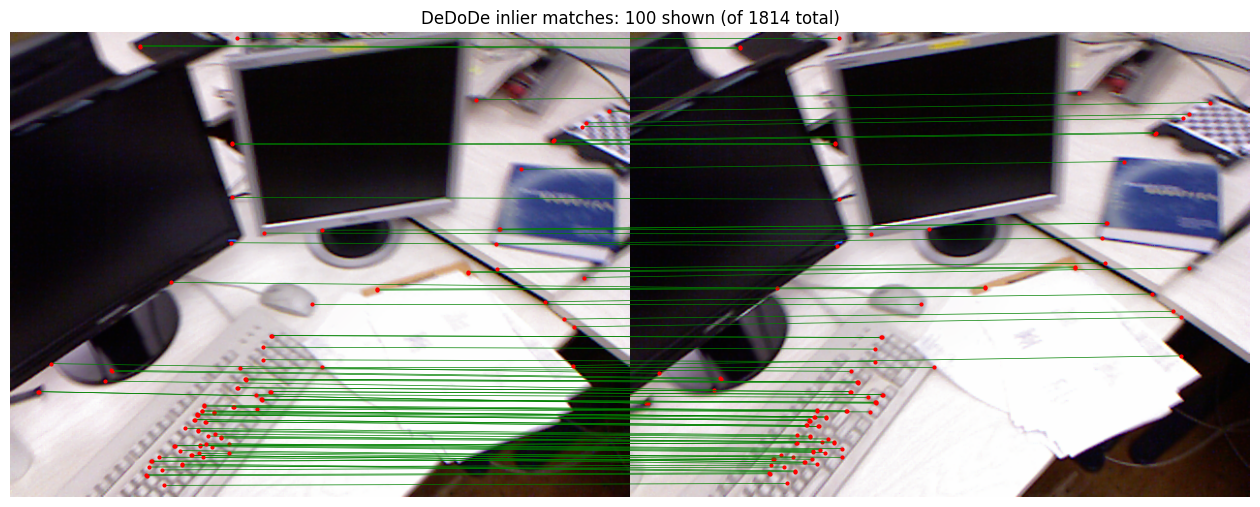

In [12]:
import matplotlib.pyplot as plt

h1, w1 = img1_rgb.shape[:2]
h2, w2 = img2_rgb.shape[:2]
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1] = img1_rgb
canvas[:h2, w1:w1+w2] = img2_rgb

inlier_idx = np.where(mask.ravel() == 1)[0]
draw_idx = inlier_idx[:100]

plt.figure(figsize=(16, 8))
plt.imshow(canvas)
for idx in draw_idx:
    x1, y1 = mkpts1[idx]
    x2, y2 = mkpts2[idx]
    plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
    plt.plot(x1, y1, 'ro', markersize=2)
    plt.plot(x2 + w1, y2, 'ro', markersize=2)
plt.title(f"DeDoDe inlier matches: {len(draw_idx)} shown (of {inliers} total)")
plt.axis('off')
plt.show()

In [13]:
import time
import pandas as pd

results_dedode = []
start_time = time.time()

for i in range(len(files) - 1):
    img1_tensor, img1_rgb_i = load_tensor(files[i])
    img2_tensor, img2_rgb_i = load_tensor(files[i+1])

    with torch.no_grad():
        kpts1, scores1 = dedode.detect(img1_tensor, n=10000)
        kpts2, scores2 = dedode.detect(img2_tensor, n=10000)
        desc1 = dedode.describe(img1_tensor, kpts1)
        desc2 = dedode.describe(img2_tensor, kpts2)

    dists, idxs = match_smnn(desc1[0], desc2[0], th=0.98)

    H, W = img1_rgb_i.shape[:2]
    kpts1_px = denormalize_kpts(kpts1[0], H, W)
    kpts2_px = denormalize_kpts(kpts2[0], H, W)

    mkpts1 = kpts1_px[idxs[:, 0]].cpu().numpy()
    mkpts2 = kpts2_px[idxs[:, 1]].cpu().numpy()

    num_matches = len(mkpts1)

    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(mkpts1, mkpts2, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0

    results_dedode.append({
        'pair_index': i,
        'frame1': files[i],
        'frame2': files[i+1],
        'num_matches': num_matches,
        'num_inliers': num_inliers,
        'inlier_ratio': inlier_ratio
    })

    if i % 50 == 0:
        elapsed = time.time() - start_time
        print(f"Pair {i}/{len(files)-1} done | elapsed: {elapsed:.1f}s")

print("Batch run complete. Total time: {:.1f}s".format(time.time() - start_time))

Pair 0/612 done | elapsed: 0.6s
Pair 50/612 done | elapsed: 44.3s
Pair 100/612 done | elapsed: 86.1s
Pair 150/612 done | elapsed: 127.5s
Pair 200/612 done | elapsed: 159.6s
Pair 250/612 done | elapsed: 200.5s
Pair 300/612 done | elapsed: 239.6s
Pair 350/612 done | elapsed: 278.3s
Pair 400/612 done | elapsed: 314.5s
Pair 450/612 done | elapsed: 353.6s
Pair 500/612 done | elapsed: 392.7s
Pair 550/612 done | elapsed: 429.6s
Pair 600/612 done | elapsed: 474.8s
Batch run complete. Total time: 486.0s


In [14]:
df_dedode = pd.DataFrame(results_dedode)
csv_path = '/content/drive/MyDrive/dedode_consecutive_pairs.csv'
df_dedode.to_csv(csv_path, index=False)

print("Saved to:", csv_path)
print(df_dedode.head())
print()
print("Summary stats:")
print(df_dedode[['num_matches', 'num_inliers', 'inlier_ratio']].describe())

Saved to: /content/drive/MyDrive/dedode_consecutive_pairs.csv
   pair_index                 frame1                 frame2  num_matches  \
0           0  1305031452.791720.png  1305031452.823674.png         2310   
1           1  1305031452.823674.png  1305031452.859642.png         2462   
2           2  1305031452.859642.png  1305031452.891726.png         2297   
3           3  1305031452.891726.png  1305031452.923715.png         3232   
4           4  1305031452.923715.png  1305031452.959701.png         4316   

   num_inliers  inlier_ratio  
0         1814      0.785281  
1         1967      0.798944  
2         1899      0.826731  
3         2763      0.854889  
4         3881      0.899212  

Summary stats:
       num_matches  num_inliers  inlier_ratio
count   612.000000   612.000000    612.000000
mean   3128.826797  2702.267974      0.840562
std    1215.310490  1173.128838      0.075730
min     140.000000    67.000000      0.466165
25%    2306.750000  1896.250000      0.808438
50%

In [16]:
def load_tensor(path_or_filename, is_full_path=False, max_dim=None):
    path = path_or_filename if is_full_path else os.path.join(dataset_dir, path_or_filename)
    img_bgr = cv2.imread(path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    if max_dim:
        h, w = img_rgb.shape[:2]
        scale = max_dim / max(h, w)
        if scale < 1:
            img_rgb = cv2.resize(img_rgb, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    return tensor.to(device), img_rgb

In [17]:
robustness_dir = '/content/drive/MyDrive/Dataset Rgb and mine'

pt_tensor, pt_rgb = load_tensor(os.path.join(robustness_dir, 'portrait-trolley.jpeg'), is_full_path=True, max_dim=1280)
t45_tensor, t45_rgb = load_tensor(os.path.join(robustness_dir, 'trolley-45-rotated.jpeg'), is_full_path=True, max_dim=1280)
zt_tensor, zt_rgb = load_tensor(os.path.join(robustness_dir, 'zoomed-trolley.jpeg'), is_full_path=True, max_dim=1280)
pw_tensor, pw_rgb = load_tensor(os.path.join(robustness_dir, 'portrait-wall.jpeg'), is_full_path=True, max_dim=1280)
r90_tensor, r90_rgb = load_tensor(os.path.join(robustness_dir, '90-rotated-wall.jpeg'), is_full_path=True, max_dim=1280)
zw_tensor, zw_rgb = load_tensor(os.path.join(robustness_dir, 'zoomed-wall.jpeg'), is_full_path=True, max_dim=1280)

print("All robustness images loaded")

All robustness images loaded


In [20]:
def denormalize_kpts(kpts, H, W):
    x = (kpts[..., 0] + 1) / 2 * (W - 1)
    y = (kpts[..., 1] + 1) / 2 * (H - 1)
    return torch.stack([x, y], dim=-1)

def run_dedode_match(img1_tensor, img1_rgb, img2_tensor, img2_rgb, n_kpts=10000):
    with torch.no_grad():
        kpts1, scores1 = dedode.detect(img1_tensor, n=n_kpts)
        kpts2, scores2 = dedode.detect(img2_tensor, n=n_kpts)
        desc1 = dedode.describe(img1_tensor, kpts1)
        desc2 = dedode.describe(img2_tensor, kpts2)

    dists, idxs = match_smnn(desc1[0], desc2[0], th=0.98)

    H1, W1 = img1_rgb.shape[:2]
    H2, W2 = img2_rgb.shape[:2]
    kpts1_px = denormalize_kpts(kpts1[0], H1, W1)
    kpts2_px = denormalize_kpts(kpts2[0], H2, W2)

    mkpts1 = kpts1_px[idxs[:, 0]].cpu().numpy()
    mkpts2 = kpts2_px[idxs[:, 1]].cpu().numpy()

    num_matches = len(mkpts1)
    if num_matches >= 8:
        F, mask = cv2.findFundamentalMat(mkpts1, mkpts2, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
        num_inliers = int(mask.sum()) if mask is not None else 0
    else:
        mask = None
        num_inliers = 0

    inlier_ratio = num_inliers / num_matches if num_matches > 0 else 0
    return mkpts1, mkpts2, mask, num_matches, num_inliers, inlier_ratio

In [21]:
dedode_robustness_results = []

res1, m1a, m1b, mask1 = run_and_report(pt_tensor, pt_rgb, t45_tensor, t45_rgb, "portrait-trolley vs trolley-45-rotated")
dedode_robustness_results.append(res1)

res2, m2a, m2b, mask2 = run_and_report(pt_tensor, pt_rgb, zt_tensor, zt_rgb, "portrait-trolley vs zoomed-trolley")
dedode_robustness_results.append(res2)

res3, m3a, m3b, mask3 = run_and_report(pw_tensor, pw_rgb, r90_tensor, r90_rgb, "portrait-wall vs 90-rotated-wall")
dedode_robustness_results.append(res3)

res4, m4a, m4b, mask4 = run_and_report(pw_tensor, pw_rgb, zw_tensor, zw_rgb, "portrait-wall vs zoomed-wall")
dedode_robustness_results.append(res4)

dedode_robustness_df = pd.DataFrame(dedode_robustness_results)
dedode_robustness_df.to_csv('/content/drive/MyDrive/dedode_robustness_tests.csv', index=False)
print(dedode_robustness_df)

--- portrait-trolley vs trolley-45-rotated ---
Matches: 178 | Inliers: 64 | Inlier ratio: 35.96%

--- portrait-trolley vs zoomed-trolley ---
Matches: 883 | Inliers: 474 | Inlier ratio: 53.68%

--- portrait-wall vs 90-rotated-wall ---
Matches: 500 | Inliers: 379 | Inlier ratio: 75.80%

--- portrait-wall vs zoomed-wall ---
Matches: 195 | Inliers: 96 | Inlier ratio: 49.23%

                                     test  matches  inliers  inlier_ratio
0  portrait-trolley vs trolley-45-rotated      178       64      0.359551
1      portrait-trolley vs zoomed-trolley      883      474      0.536806
2        portrait-wall vs 90-rotated-wall      500      379      0.758000
3            portrait-wall vs zoomed-wall      195       96      0.492308


In [23]:
import matplotlib.pyplot as plt

def visualize_matches(img1_rgb, img2_rgb, mkpts1, mkpts2, mask, label, max_draw=100):
    h1, w1 = img1_rgb.shape[:2]
    h2, w2 = img2_rgb.shape[:2]
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1_rgb
    canvas[:h2, w1:w1+w2] = img2_rgb

    inlier_idx = np.where(mask.ravel() == 1)[0]
    draw_idx = np.random.choice(inlier_idx, size=min(max_draw, len(inlier_idx)), replace=False)

    plt.figure(figsize=(16, 8))
    plt.imshow(canvas)
    for idx in draw_idx:
        x1, y1 = mkpts1[idx]
        x2, y2 = mkpts2[idx]
        plt.plot([x1, x2 + w1], [y1, y2], 'g-', linewidth=0.5)
        plt.plot(x1, y1, 'ro', markersize=2)
        plt.plot(x2 + w1, y2, 'ro', markersize=2)
    plt.title(f"DeDoDe: {label} — {len(draw_idx)} inliers shown (of {int(mask.sum())} total)")
    plt.axis('off')
    plt.show()

In [24]:
visualize_matches(pt_rgb, t45_rgb, m1a, m1b, mask1, "trolley normal vs rotated")
visualize_matches(pt_rgb, zt_rgb, m2a, m2b, mask2, "trolley normal vs zoomed")
visualize_matches(pw_rgb, r90_rgb, m3a, m3b, mask3, "wall normal vs rotated")
visualize_matches(pw_rgb, zw_rgb, m4a, m4b, mask4, "wall normal vs zoomed")

Output hidden; open in https://colab.research.google.com to view.